# Hotel Reviewer Score Prediction (Booking.com)

**Aim:** To build and compare CNN, LSTM, and GRU deep learning models for predicting reviewer scores using textual hotel reviews and selected numerical features, followed by hyperparameter optimisation.

**Deliverables:** EDA, preprocessing pipeline, baseline vs tuned models, and final evaluation using MSE, RMSE, and R².


In [1]:

# Core
import os
import re
import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


## Dataset Loading

In [2]:
import pandas as pd
import os

file_path = r"C:\Users\peeye\Desktop\ODL\Hotel_Reviews.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    print("✅ Dataset loaded successfully!")
    print("Shape:", df.shape)
    display(df.head())
else:
    print("❌ File not found!")
    print("Path checked:", file_path)


✅ Dataset loaded successfully!
Shape: (515738, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


### sanity checks

## Dataset Loading
The Booking.com hotel reviews dataset is loaded and inspected to understand its structure, data types, and completeness before preprocessing.


In [3]:
df.info()
df.isna().sum().sort_values(ascending=False).head(20)
df.describe(include="all").T.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hotel_Address,515738,1493,163 Marsh Wall Docklands Tower Hamlets London ...,4789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additional_Number_of_Scoring,515738.0,NaN,NaN,NaN,498.081836,500.538467,1.0,169.0,341.0,660.0,2682.0
Review_Date,515738,731,8/2/2017,2585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Average_Score,515738.0,NaN,NaN,NaN,8.397487,0.548048,5.2,8.1,8.4,8.8,9.8
Hotel_Name,515738,1492,Britannia International Hotel Canary Wharf,4789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer_Nationality,515738,227,United Kingdom,245246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Negative_Review,515738,330011,No Negative,127890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review_Total_Negative_Word_Counts,515738.0,NaN,NaN,NaN,18.53945,29.690831,0.0,2.0,9.0,23.0,408.0
Total_Number_of_Reviews,515738.0,NaN,NaN,NaN,2743.743944,2317.464868,43.0,1161.0,2134.0,3613.0,16670.0
Positive_Review,515738,412601,No Positive,35946,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Text Data Cleaning
Positive and negative reviews are combined into a single textual feature. Missing values and placeholder text are removed to ensure clean and meaningful text input for neural networks.


In [ ]:
for col in ["Negative_Review", "Positive_Review"]:
    df[col] = df[col].fillna("").astype(str)
    df[col] = df[col].replace({"No Negative": "", "No Positive": ""})


df["review_text"] = (df["Positive_Review"] + " " + df["Negative_Review"]).str.strip()


df = df[df["review_text"].str.len() > 0].copy()

print("✅ After cleaning:", df.shape)


✅ After cleaning: (515501, 18)


## Exploratory Data Analysis (EDA)
This section explores score distribution, key review terms, review lengths, and correlations among selected numeric features to inform model design choices.


### Distribution of Reviewer_Score

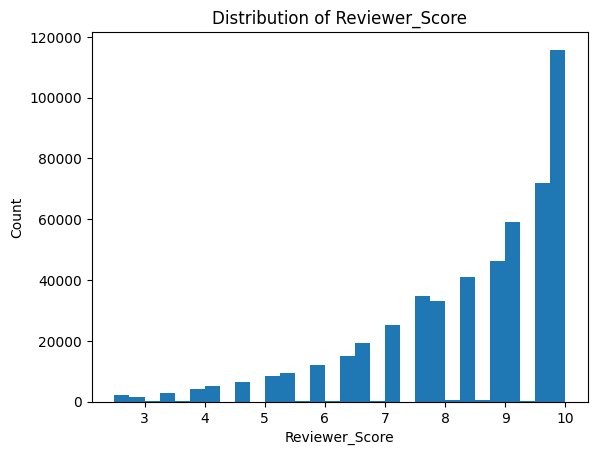

In [5]:
plt.figure()
plt.hist(df["Reviewer_Score"].dropna(), bins=30)
plt.title("Distribution of Reviewer_Score")
plt.xlabel("Reviewer_Score")
plt.ylabel("Count")
plt.show()


### Textual Review Exploration

In [83]:
df["review_length"] = df["review_text"].apply(len)
df["review_length"].describe()


count    515501.000000
mean        184.107916
std         200.191397
min           1.000000
25%          62.000000
50%         124.000000
75%         233.000000
max        3804.000000
Name: review_length, dtype: float64

### Word Clouds (Positive vs Negative)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


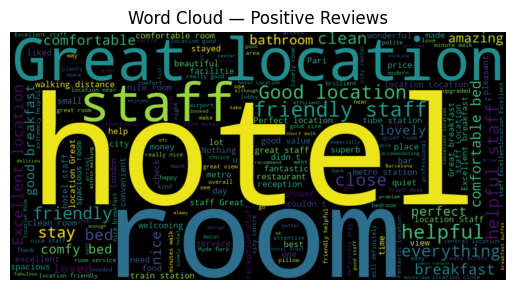

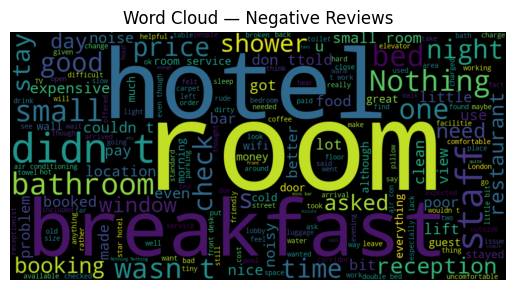

In [6]:
!pip -q install wordcloud
from wordcloud import WordCloud

pos_text = " ".join(df["Positive_Review"].astype(str).tolist())
neg_text = " ".join(df["Negative_Review"].astype(str).tolist())

wc_pos = WordCloud(width=1000, height=500).generate(pos_text)
plt.figure()
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Positive Reviews")
plt.show()

wc_neg = WordCloud(width=1000, height=500).generate(neg_text)
plt.figure()
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Negative Reviews")
plt.show()


<Axes: >

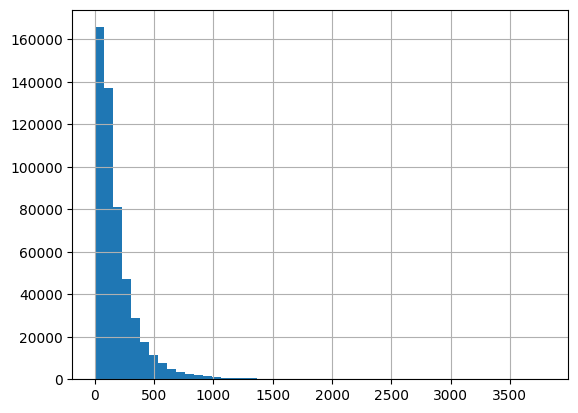

In [84]:
df["review_length"].hist(bins=50)


### Correlation heatmap

In [9]:
import numpy as np

num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()


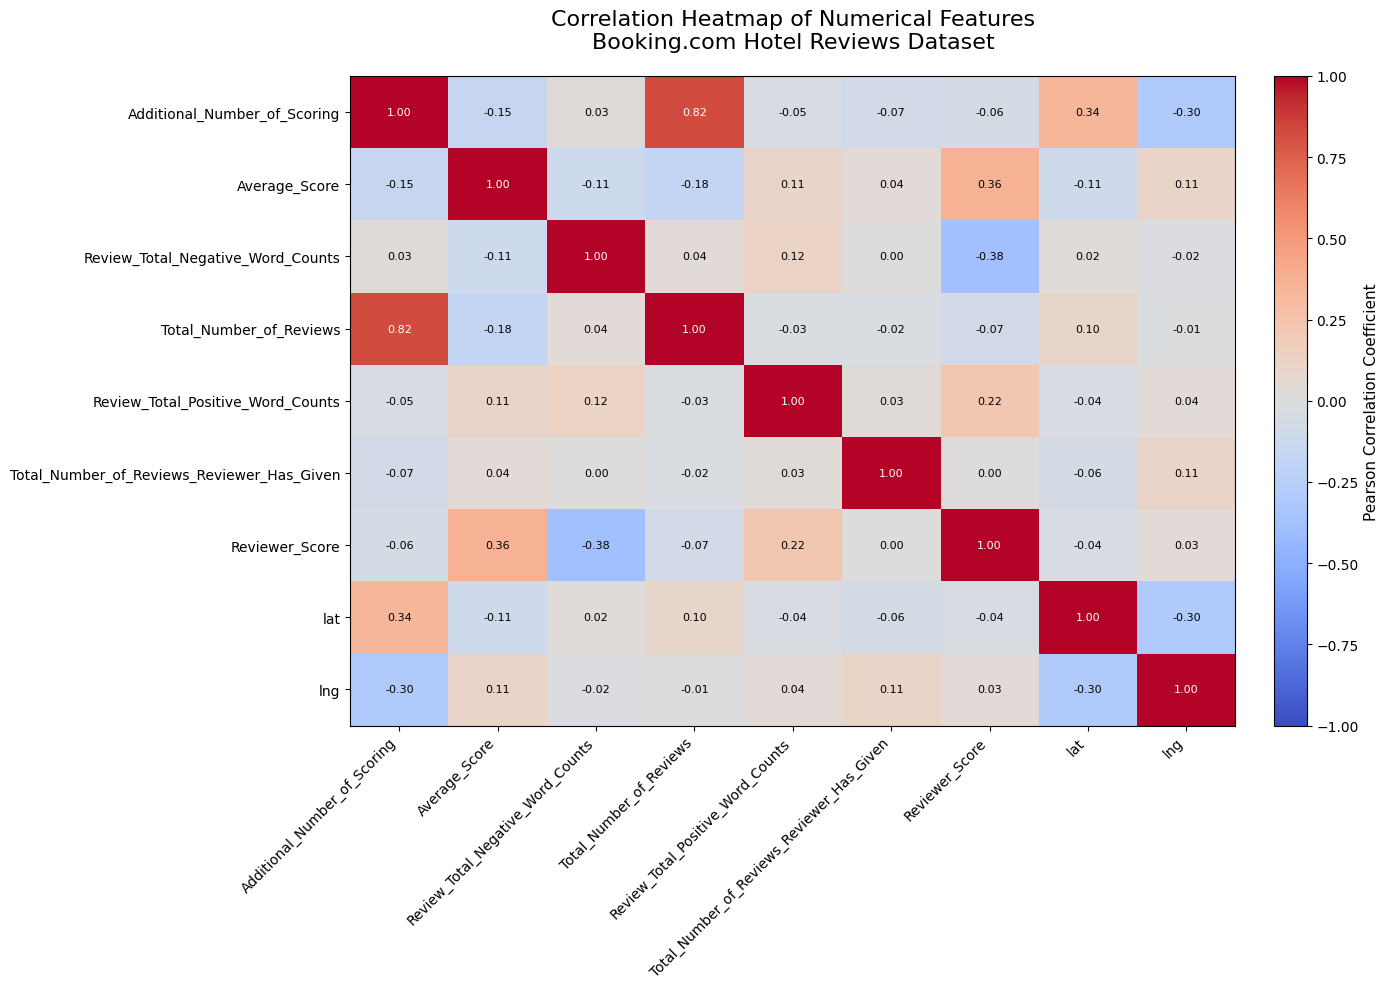

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 10))

im = plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.title(
    "Correlation Heatmap of Numerical Features\nBooking.com Hotel Reviews Dataset",
    fontsize=16,
    pad=20
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=10
)


for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if abs(value) >= 0.60 else "black"
        )

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Pearson Correlation Coefficient", fontsize=11)

plt.tight_layout()
plt.show()


In [11]:
lengths = df["review_text"].astype(str).apply(lambda x: len(x.split()))
lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


count    515501.000000
mean         33.694468
std          38.434954
min           1.000000
50%          22.000000
90%          74.000000
95%         102.000000
99%         187.000000
max         733.000000
Name: review_text, dtype: float64

In [12]:
y = df["Reviewer_Score"].astype(float).values


In [14]:
import sys
print(sys.executable)


c:\Users\peeye\AppData\Local\Programs\Python\Python310\python.exe


In [ ]:
!python -m pip install --upgrade pip
!python -m pip install tensorflow


### Tokenisation and Sequence Padding
Text reviews are converted into integer sequences using a tokenizer and padded to a fixed length so that they can be processed by deep learning models.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = df["review_text"].astype(str).tolist()

VOCAB = 50000
tokenizer = Tokenizer(num_words=VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

seqs = tokenizer.texts_to_sequences(texts)

MAXLEN = 200  
X_text = pad_sequences(seqs, maxlen=MAXLEN, padding="post", truncating="post")

print("✅ X_text:", X_text.shape)


✅ X_text: (515501, 200)


## Data Preparation and Preprocessing

In [17]:
df.columns


Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng', 'review_text'],
      dtype='object')

In [18]:
num_cols = ["lat", "lng", "Average_Score"]  # adjust if your column names differ
X_num = df[num_cols].copy()

scaler = MinMaxScaler()
X_num_scaled = scaler.fit_transform(X_num)

print("✅ X_num_scaled:", X_num_scaled.shape)


✅ X_num_scaled: (515501, 3)


### Dataset Splitting
The dataset is split into training, validation, and test sets to allow unbiased model training, tuning, and final evaluation.


In [19]:
X_text_train, X_text_temp, X_num_train, X_num_temp, y_train, y_temp = train_test_split(
    X_text, X_num_scaled, y, test_size=0.2, random_state=42
)

X_text_val, X_text_test, X_num_val, X_num_test, y_val, y_test = train_test_split(
    X_text_temp, X_num_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_text_train.shape, X_num_train.shape, y_train.shape)
print("Val:  ", X_text_val.shape, X_num_val.shape, y_val.shape)
print("Test: ", X_text_test.shape, X_num_test.shape, y_test.shape)


Train: (412400, 200) (412400, 3) (412400,)
Val:   (51550, 200) (51550, 3) (51550,)
Test:  (51551, 200) (51551, 3) (51551,)


## Baseline CNN Model
A Convolutional Neural Network (CNN) is implemented as a baseline model to capture local textual patterns using convolutional filters.


In [20]:
from tensorflow.keras import layers, Model, Input

EMB_DIM = 128

text_in = Input(shape=(MAXLEN,), name="text_in")
x = layers.Embedding(VOCAB, EMB_DIM)(text_in)
x = layers.Conv1D(128, kernel_size=5, activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)

num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
n = layers.Dense(16, activation="relu")(num_in)

z = layers.Concatenate()([x, n])
z = layers.Dense(64, activation="relu")(z)
out = layers.Dense(1, name="score")(z)

cnn_model = Model([text_in, num_in], out)
cnn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
cnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_in             │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  6,400,000 │ text_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 196, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,491,457 (24.76 MB)

 Trainable params: 6,491,457 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
callbacks = [tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]

hist_cnn = cnn_model.fit(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    epochs=10, batch_size=256, callbacks=callbacks, verbose=1
)


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - loss: 0.4921 - mae: 0.5120 - val_loss: 1.2334 - val_mae: 0.8144
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - loss: 0.4468 - mae: 0.4846 - val_loss: 1.2526 - val_mae: 0.8205
Epoch 3/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - loss: 0.4127 - mae: 0.4631 - val_loss: 1.2752 - val_mae: 0.8377


In [63]:
cnn_to_eval = cnn_model
cnn_label = "CNN"
cnn_version = "Baseline"


In [64]:
y_pred_cnn = cnn_to_eval.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [65]:
cnn_mse = mean_squared_error(y_test, y_pred_cnn)
cnn_rmse = np.sqrt(cnn_mse)
cnn_r2 = r2_score(y_test, y_pred_cnn)

print(f"{cnn_label} ({cnn_version}) Metrics")
print(f"MSE  : {cnn_mse:.4f}")
print(f"RMSE : {cnn_rmse:.4f}")
print(f"R²   : {cnn_r2:.4f}")


CNN (Baseline) Metrics
MSE  : 1.2233
RMSE : 1.1060
R²   : 0.5408


## Baseline LSTM Model
The LSTM model is used to capture sequential dependencies in review text, enabling the modelling of long-term contextual relationships.


In [26]:
text_in = Input(shape=(MAXLEN,), name="text_in")
x = layers.Embedding(VOCAB, EMB_DIM)(text_in)
x = layers.LSTM(128)(x)

num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
n = layers.Dense(16, activation="relu")(num_in)

z = layers.Concatenate()([x, n])
z = layers.Dense(64, activation="relu")(z)
out = layers.Dense(1, name="score")(z)

lstm_model = Model([text_in, num_in], out)
lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_in             │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  6,400,000 │ text_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    131,584 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         64 │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 144)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      9,280 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,540,993 (24.95 MB)

 Trainable params: 6,540,993 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
hist_lstm = lstm_model.fit(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    epochs=10, batch_size=256, callbacks=callbacks, verbose=1
)


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 1017s 631ms/step - loss: 2.6792 - mae: 1.3132 - val_loss: 2.6650 - val_mae: 1.3173
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 958s 595ms/step - loss: 2.6715 - mae: 1.3112 - val_loss: 2.6792 - val_mae: 1.2902


In [69]:
lstm_to_eval = lstm_model
lstm_label = "LSTM"
lstm_version = "Baseline"


In [70]:
y_pred_lstm = lstm_to_eval.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step


In [71]:
lstm_mse = mean_squared_error(y_test, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test, y_pred_lstm)

print(f"{lstm_label} ({lstm_version}) Metrics")
print(f"MSE  : {lstm_mse:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")


LSTM (Baseline) Metrics
MSE  : 2.6576
RMSE : 1.6302
R²   : 0.0024


Plot learning curves

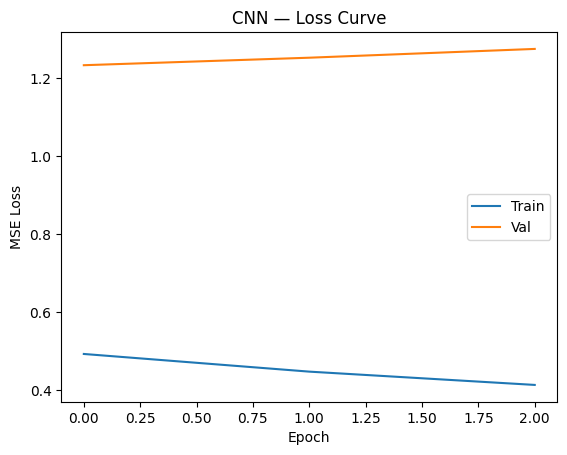

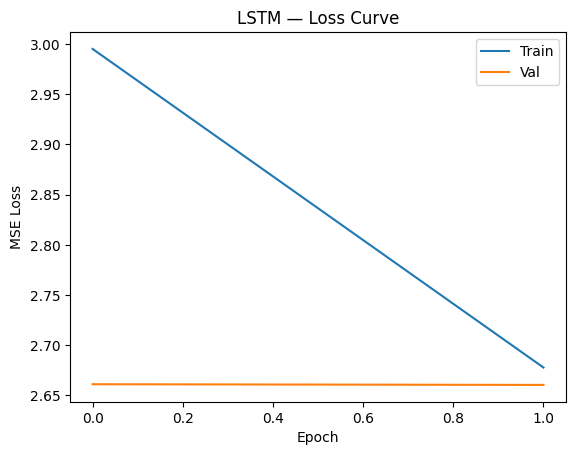

In [ ]:
def plot_history(hist, title):
    plt.figure()
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend(["Train", "Val"])
    plt.show()

plot_history(hist_cnn, "CNN — Loss Curve")
plot_history(hist_lstm, "LSTM — Loss Curve")


Evaluate on test set + comparison table

In [29]:
cnn_test = cnn_model.evaluate({"text_in": X_text_test, "num_in": X_num_test}, y_test, verbose=0)
lstm_test = lstm_model.evaluate({"text_in": X_text_test, "num_in": X_num_test}, y_test, verbose=0)

results = pd.DataFrame([
    {"Model":"1D-CNN", "Version":"Baseline", "Test_MSE":cnn_test[0], "Test_MAE":cnn_test[1]},
    {"Model":"LSTM",   "Version":"Baseline", "Test_MSE":lstm_test[0], "Test_MAE":lstm_test[1]},
])

results


,Model,Version,Test_MSE,Test_MAE
0,1D-CNN,Baseline,1.223347,0.809342
1,LSTM,Baseline,2.653662,1.312344


In [35]:
results.to_csv("baseline_results.csv", index=False)


**Baseline CNN Summary:**  
The baseline CNN captures local textual features effectively but has limited ability to model long-range dependencies across lengthy reviews.


Hyperparameter Optimisation (Keras Tuner)

In [36]:
!pip -q install keras-tuner
import keras_tuner as kt


### CNN Tuning

In [37]:
def build_cnn(hp):
    text_in = Input(shape=(MAXLEN,), name="text_in")
    emb_dim = hp.Choice("emb_dim", [64, 128, 256])
    x = layers.Embedding(VOCAB, emb_dim)(text_in)

    filters = hp.Choice("filters", [64, 128, 256])
    ksize = hp.Choice("kernel_size", [3, 5, 7])
    x = layers.Conv1D(filters, kernel_size=ksize, activation="relu")(x)

    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(hp.Float("dropout", 0.1, 0.5, step=0.1))(x)

    num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
    n = layers.Dense(hp.Choice("num_dense", [8, 16, 32]), activation="relu")(num_in)

    z = layers.Concatenate()([x, n])
    z = layers.Dense(hp.Choice("dense", [32, 64, 128]), activation="relu")(z)
    out = layers.Dense(1)(z)

    model = Model([text_in, num_in], out)
    lr = hp.Choice("lr", [1e-4, 3e-4, 1e-3, 3e-3])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

tuner = kt.Hyperband(
    build_cnn,
    objective="val_loss",
    max_epochs=8,
    factor=3,
    directory="kt_dir",
    project_name="cnn_tuning"
)

tuner.search(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    batch_size=256,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
)


Trial 10 Complete [00h 10m 21s]
val_loss: 6.864304542541504

Best val_loss So Far: 1.130956768989563
Total elapsed time: 01h 22m 12s


In [38]:
best_cnn = tuner.get_best_models(num_models=1)[0]
best_cnn_hist = best_cnn.fit(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    epochs=10, batch_size=256,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
)


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 97s 60ms/step - loss: 1.0982 - mae: 0.7984 - val_loss: 1.1163 - val_mae: 0.7940
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - loss: 1.0319 - mae: 0.7725 - val_loss: 1.1273 - val_mae: 0.7920
Epoch 3/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - loss: 0.9631 - mae: 0.7441 - val_loss: 1.1274 - val_mae: 0.8013


In [66]:
cnn_to_eval = best_cnn
cnn_label = "CNN"
cnn_version = "Tuned"


In [67]:
y_pred_cnn = cnn_to_eval.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [68]:
cnn_mse = mean_squared_error(y_test, y_pred_cnn)
cnn_rmse = np.sqrt(cnn_mse)
cnn_r2 = r2_score(y_test, y_pred_cnn)

print(f"{cnn_label} ({cnn_version}) Metrics")
print(f"MSE  : {cnn_mse:.4f}")
print(f"RMSE : {cnn_rmse:.4f}")
print(f"R²   : {cnn_r2:.4f}")


CNN (Tuned) Metrics
MSE  : 1.1039
RMSE : 1.0507
R²   : 0.5856


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 71s 44ms/step - loss: 1.0285 - mae: 0.7707 - val_loss: 1.1342 - val_mae: 0.8116
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - loss: 0.9663 - mae: 0.7456 - val_loss: 1.1295 - val_mae: 0.7992


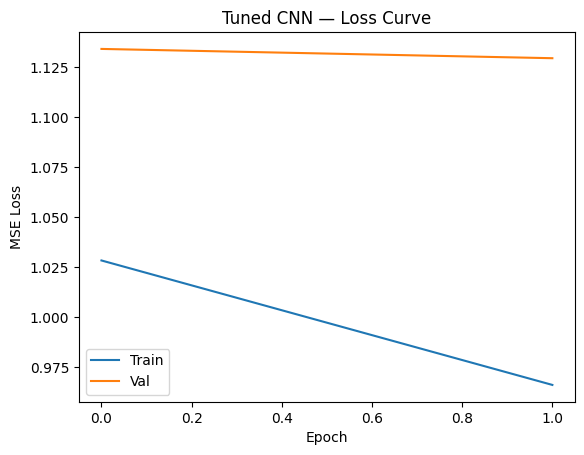

In [ ]:
hist_cnn_tuned = best_cnn.fit(
    {"text_in": X_text_train, "num_in": X_num_train},
    y_train,
    validation_data=(
        {"text_in": X_text_val, "num_in": X_num_val},
        y_val
    ),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


plt.figure()
plt.plot(hist_cnn_tuned.history["loss"])
plt.plot(hist_cnn_tuned.history["val_loss"])
plt.title("Tuned CNN — Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train", "Val"])
plt.show()


### LSTM Tuning

In [ ]:
def build_lstm(hp):
    text_in = Input(shape=(MAXLEN,), name="text_in")

    emb_dim = hp.Choice("emb_dim", [64, 128, 256])
    x = layers.Embedding(VOCAB, emb_dim)(text_in)

    lstm_units = hp.Choice("lstm_units", [64, 128, 256])
    x = layers.LSTM(lstm_units)(x)

    x = layers.Dropout(hp.Float("dropout", 0.1, 0.5, step=0.1))(x)

   
    num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
    n = layers.Dense(
        hp.Choice("num_dense", [8, 16, 32]),
        activation="relu"
    )(num_in)

   
    z = layers.Concatenate()([x, n])
    z = layers.Dense(
        hp.Choice("dense", [32, 64, 128]),
        activation="relu"
    )(z)

    out = layers.Dense(1)(z)

    model = Model([text_in, num_in], out)

   
    lr = hp.Choice("lr", [1e-4, 3e-4, 1e-3, 3e-3])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

tuner_lstm = kt.Hyperband(
    build_lstm,
    objective="val_loss",
    max_epochs=8,
    factor=3,
    directory="kt_dir",
    project_name="lstm_tuning"
)

tuner_lstm.search(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    batch_size=256,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)]
)


Trial 10 Complete [01h 05m 06s]
val_loss: 1.160262942314148

Best val_loss So Far: 1.0658622980117798
Total elapsed time: 05h 56m 59s


In [ ]:
best_lstm = tuner_lstm.get_best_models(num_models=1)[0]




In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [72]:
lstm_to_eval = best_lstm
lstm_label = "LSTM"
lstm_version = "Tuned"


In [73]:
y_pred_lstm = lstm_to_eval.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 65s 40ms/step


In [74]:
lstm_mse = mean_squared_error(y_test, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test, y_pred_lstm)

print(f"{lstm_label} ({lstm_version}) Metrics")
print(f"MSE  : {lstm_mse:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")


LSTM (Tuned) Metrics
MSE  : 1.0641
RMSE : 1.0315
R²   : 0.6006


In [ ]:

y_pred_lstm = best_lstm.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 64s 40ms/step


In [ ]:

mse_lstm = mean_squared_error(y_test, y_pred_lstm)


rmse_lstm = np.sqrt(mse_lstm)


r2_lstm = r2_score(y_test, y_pred_lstm)

print("Tuned LSTM Evaluation Metrics")
print(f"MSE  : {mse_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f}")
print(f"R²   : {r2_lstm:.4f}")


Tuned LSTM Evaluation Metrics
MSE  : 1.0641
RMSE : 1.0315
R²   : 0.6006


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 751s 466ms/step - loss: 0.9689 - mae: 0.7404 - val_loss: 1.0711 - val_mae: 0.7693
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 753s 467ms/step - loss: 0.8934 - mae: 0.7080 - val_loss: 1.0777 - val_mae: 0.7664


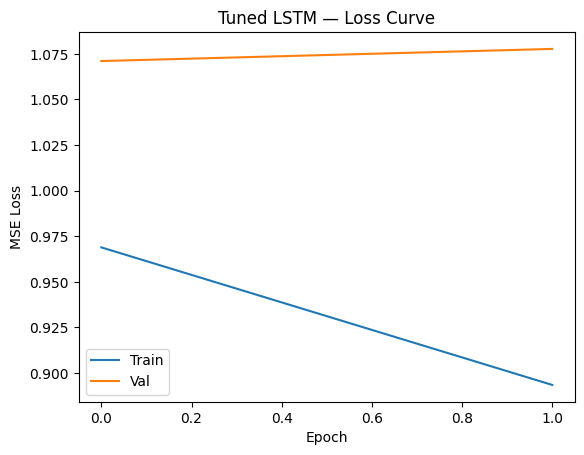

In [ ]:

hist_lstm_tuned = best_lstm.fit(
    {"text_in": X_text_train, "num_in": X_num_train},
    y_train,
    validation_data=(
        {"text_in": X_text_val, "num_in": X_num_val},
        y_val
    ),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


plt.figure()
plt.plot(hist_lstm_tuned.history["loss"])
plt.plot(hist_lstm_tuned.history["val_loss"])
plt.title("Tuned LSTM — Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train", "Val"])
plt.show()


In [ ]:
results_lstm = pd.DataFrame([{
    "Model": "LSTM",
    "Version": "Tuned",
    "MSE": mse_lstm,
    "RMSE": rmse_lstm,
    "R2": r2_lstm
}])

results_lstm


In [46]:
comparison = pd.DataFrame({
    "Actual_Score": y_test[:10],
    "Predicted_Score": y_pred_lstm[:10]
})

comparison


,Actual_Score,Predicted_Score
0,10.0,9.600063
1,10.0,9.701490
2,5.8,5.501902
3,10.0,9.535500
4,10.0,8.073650
5,9.6,9.481916
6,8.8,8.684302
7,7.1,8.032774
8,10.0,9.050158
9,8.8,8.079107


## Baseline GRU Model
This model captures sequential dependencies efficiently with fewer parameters than LSTM.

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


### GRU Tuning

In [ ]:


text_in = Input(shape=(MAXLEN,), name="text_in")

x = layers.Embedding(VOCAB, EMB_DIM)(text_in)

x = layers.GRU(128)(x)

x = layers.Dropout(0.2)(x)

num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
n = layers.Dense(16, activation="relu")(num_in)

z = layers.Concatenate()([x, n])
z = layers.Dense(64, activation="relu")(z)

out = layers.Dense(1, name="score")(z)

gru_model = Model([text_in, num_in], out)

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_in             │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  6,400,000 │ text_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     99,072 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         64 │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 144)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      9,280 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,508,481 (24.83 MB)

 Trainable params: 6,508,481 (24.83 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=2,
        restore_best_weights=True
    )
]

hist_gru = gru_model.fit(
    {"text_in": X_text_train, "num_in": X_num_train},
    y_train,
    validation_data=(
        {"text_in": X_text_val, "num_in": X_num_val},
        y_val
    ),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 364s 225ms/step - loss: 1.9262 - mae: 1.0028 - val_loss: 1.3304 - val_mae: 0.9341
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 352s 218ms/step - loss: 1.1484 - mae: 0.8126 - val_loss: 1.3639 - val_mae: 0.9548
Epoch 3/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 351s 218ms/step - loss: 1.0327 - mae: 0.7675 - val_loss: 1.3508 - val_mae: 0.9442


In [50]:
gru_test_mse, gru_test_mae = gru_model.evaluate(
    {"text_in": X_text_test, "num_in": X_num_test},
    y_test,
    verbose=0
)

print(f"GRU Test MSE: {gru_test_mse:.4f}")
print(f"GRU Test MAE: {gru_test_mae:.4f}")


GRU Test MSE: 1.3413
GRU Test MAE: 0.9361


In [51]:
y_pred_gru = gru_model.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step


In [ ]:
gru_mse = mean_squared_error(y_test, y_pred_gru)
gru_rmse = np.sqrt(gru_mse)
gru_r2 = r2_score(y_test, y_pred_gru)

print("GRU Baseline Evaluation Metrics")
print(f"MSE  : {gru_mse:.4f}")
print(f"RMSE : {gru_rmse:.4f}")
print(f"R²   : {gru_r2:.4f}")


GRU Evaluation Metrics
MSE  : 1.3413
RMSE : 1.1582
R²   : 0.4965


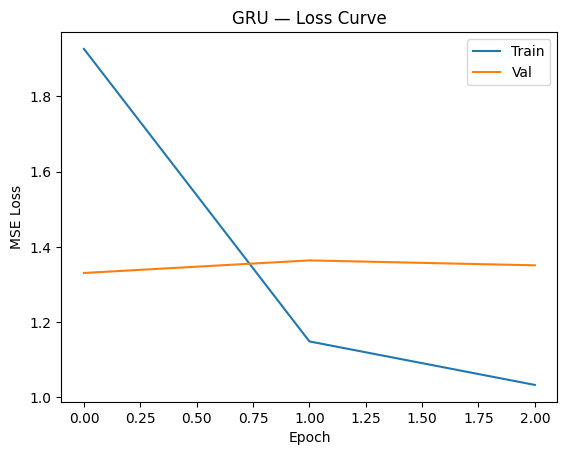

In [78]:
plot_history(hist_gru, "GRU — Loss Curve")


Tuner for GRU

In [54]:
!pip -q install keras-tuner

import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input


In [ ]:
## Baseline GRU Model
The GRU model provides a simplified recurrent architecture designed to efficiently capture sequence information with fewer parameters than LSTM.


In [55]:
def build_gru(hp):
    # ---- Text branch ----
    text_in = Input(shape=(MAXLEN,), name="text_in")

    emb_dim = hp.Choice("emb_dim", [64, 128, 256])
    x = layers.Embedding(VOCAB, emb_dim)(text_in)

    gru_units = hp.Choice("gru_units", [64, 128, 256])
    x = layers.GRU(gru_units)(x)

    dropout = hp.Float("dropout", 0.1, 0.5, step=0.1)
    x = layers.Dropout(dropout)(x)

    # ---- Numeric branch ----
    num_in = Input(shape=(X_num_train.shape[1],), name="num_in")
    n = layers.Dense(
        hp.Choice("num_dense", [8, 16, 32]),
        activation="relu"
    )(num_in)

    # ---- Combine ----
    z = layers.Concatenate()([x, n])

    dense_units = hp.Choice("dense", [32, 64, 128])
    z = layers.Dense(dense_units, activation="relu")(z)

    out = layers.Dense(1, name="score")(z)

    model = Model([text_in, num_in], out)

    lr = hp.Choice("lr", [1e-4, 3e-4, 1e-3, 3e-3])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


## Hyperparameter Optimisation
Hyperparameter optimisation is performed using Keras Tuner (Hyperband) to identify optimal model configurations based on validation loss.


In [56]:
tuner_gru = kt.Hyperband(
    build_gru,
    objective="val_loss",
    max_epochs=8,
    factor=3,
    directory="kt_dir",
    project_name="gru_tuning"
)


In [57]:
tuner_gru.search(
    {"text_in": X_text_train, "num_in": X_num_train}, y_train,
    validation_data=({"text_in": X_text_val, "num_in": X_num_val}, y_val),
    batch_size=256,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)


Trial 10 Complete [00h 22m 26s]
val_loss: 1.038865089416504

Best val_loss So Far: 1.038865089416504
Total elapsed time: 04h 10m 43s


In [75]:
# Keras evaluation (MSE + MAE)
gru_test_mse, gru_test_mae = best_gru.evaluate(
    {"text_in": X_text_test, "num_in": X_num_test},
    y_test,
    verbose=0
)

# Predictions for RMSE + R2
y_pred_gru_tuned = best_gru.predict(
    {"text_in": X_text_test, "num_in": X_num_test}
).flatten()

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

gru_mse = mean_squared_error(y_test, y_pred_gru_tuned)
gru_rmse = np.sqrt(gru_mse)
gru_r2 = r2_score(y_test, y_pred_gru_tuned)

print("Tuned GRU Evaluation Metrics")
print(f"MSE  : {gru_mse:.4f}")
print(f"RMSE : {gru_rmse:.4f}")
print(f"R²   : {gru_r2:.4f}")
print(f"(Keras) Test MSE: {gru_test_mse:.4f}, Test MAE: {gru_test_mae:.4f}")


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step
Tuned GRU Evaluation Metrics
MSE  : 1.0447
RMSE : 1.0221
R²   : 0.6079
(Keras) Test MSE: 1.0447, Test MAE: 0.7669


## Final Evaluation Summary
The tuned GRU model achieved the lowest prediction error and highest R² value among all evaluated models, indicating superior generalisation performance. These findings are consistent with the results reported in the written document.


In [58]:
best_hp_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
print("Best GRU hyperparameters:")
for k, v in best_hp_gru.values.items():
    print(f"  {k}: {v}")

best_gru = tuner_gru.get_best_models(num_models=1)[0]
best_gru.summary()


Best GRU hyperparameters:
  emb_dim: 64
  gru_units: 128
  dropout: 0.1
  num_dense: 16
  dense: 32
  lr: 0.003
  tuner/epochs: 8
  tuner/initial_epoch: 0
  tuner/bracket: 0
  tuner/round: 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_in             │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 64)   │  3,200,000 │ text_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │     74,496 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,279,233 (12.51 MB)

 Trainable params: 3,279,233 (12.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 887s 551ms/step - loss: 0.9474 - mae: 0.7311 - val_loss: 1.0689 - val_mae: 0.7500
Epoch 2/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 730s 453ms/step - loss: 0.8600 - mae: 0.6941 - val_loss: 1.0764 - val_mae: 0.7509
Epoch 3/10
1611/1611 ━━━━━━━━━━━━━━━━━━━━ 329s 204ms/step - loss: 0.7838 - mae: 0.6599 - val_loss: 1.0732 - val_mae: 0.7609


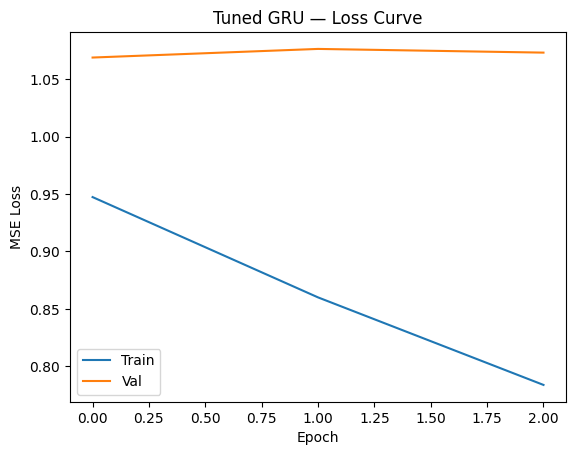

In [ ]:

hist_gru_tuned = best_gru.fit(
    {"text_in": X_text_train, "num_in": X_num_train},
    y_train,
    validation_data=(
        {"text_in": X_text_val, "num_in": X_num_val},
        y_val
    ),
    epochs=10,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


plt.figure()
plt.plot(hist_gru_tuned.history["loss"])
plt.plot(hist_gru_tuned.history["val_loss"])
plt.title("Tuned GRU — Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train", "Val"])
plt.show()
